In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt

with open('../datasets/mod_05_topic_10_various_data.pkl', 'rb') as fl:
    datasets = pickle.load(fl)

In [2]:
datasets.keys()

dict_keys(['autos', 'concrete', 'customer', 'accidents'])

In [3]:
df = datasets['autos']
df

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9,114,5400,23,28,16845
189,volvo,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8,160,5300,19,25,19045
190,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8,134,5500,18,23,21485
191,volvo,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.40,23,106,4800,26,27,22470


In [4]:
print(df.describe())

       num_of_doors  wheel_base      length       width      height  \
count    193.000000  193.000000  193.000000  193.000000  193.000000   
mean       3.160622   98.923834  174.326425   65.893782   53.869948   
std        0.989583    6.152409   12.478593    2.137795    2.394770   
min        2.000000   86.600000  141.100000   60.300000   47.800000   
25%        2.000000   94.500000  166.300000   64.100000   52.000000   
50%        4.000000   97.000000  173.200000   65.400000   54.100000   
75%        4.000000  102.400000  184.600000   66.900000   55.700000   
max        4.000000  120.900000  208.100000   72.000000   59.800000   

       curb_weight  num_of_cylinders  engine_size        bore      stroke  \
count   193.000000        193.000000   193.000000  193.000000  193.000000   
mean   2561.507772          4.419689   128.124352    3.330622    3.248860   
std     526.700026          1.023182    41.590452    0.272385    0.315421   
min    1488.000000          3.000000    61.000000   

In [5]:
# Визначення цільової змінної
y = df['price']
X = df.drop('price', axis=1)

In [6]:
# Дискретні ознаки — ті, що мають малу кількість унікальних значень як
discrete_features = [col for col in X.columns if X[col].nunique() < 25]
print(discrete_features)

['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders', 'fuel_system', 'compression_ratio', 'peak_rpm']


In [7]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Кодування дискретних змінних
X_encoded = X.copy()
for col in discrete_features:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col])


In [8]:
X_encoded

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,0,1,0,2,0,2,0,88.6,168.8,64.1,...,4,130,4,3.47,2.68,9,111,5000,21,27
1,0,1,0,2,0,2,0,88.6,168.8,64.1,...,4,130,4,3.47,2.68,9,111,5000,21,27
2,0,1,0,2,2,2,0,94.5,171.2,65.5,...,6,152,4,2.68,3.47,9,154,5000,19,26
3,1,1,0,4,3,1,0,99.8,176.6,66.2,...,4,109,4,3.19,3.40,10,102,5500,24,30
4,1,1,0,4,3,0,0,99.4,176.6,66.4,...,5,136,4,3.19,3.40,8,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,20,1,0,4,3,2,0,109.1,188.8,68.9,...,4,141,4,3.78,3.15,9,114,5400,23,28
189,20,1,1,4,3,2,0,109.1,188.8,68.8,...,4,141,4,3.78,3.15,8,160,5300,19,25
190,20,1,0,4,3,2,0,109.1,188.8,68.9,...,6,173,4,3.58,2.87,8,134,5500,18,23
191,20,0,1,4,3,2,0,109.1,188.8,68.9,...,6,145,2,3.01,3.40,23,106,4800,26,27


Mutual Information Scores (sorted):
curb_weight: 0.9183353718171889
engine_size: 0.9013185800305044
horsepower: 0.8998386957288207
highway_mpg: 0.8872404069321451
city_mpg: 0.7669866112274208
width: 0.6868731005920239
length: 0.6142491605581459
wheel_base: 0.5838541933134285
make: 0.5432331033556093
bore: 0.5006890154042116
fuel_system: 0.4826860040920098
peak_rpm: 0.4458728290318037
stroke: 0.37618206329839854
height: 0.3687611580277874
num_of_cylinders: 0.3328996764553589
drive_wheels: 0.3324483494132857
engine_type: 0.15052359862133735
compression_ratio: 0.1321835897222332
aspiration: 0.08775535132818213
body_style: 0.08056945535153215
fuel_type: 0.04727906419318595
engine_location: 0.036912063539393025
num_of_doors: 0.012704774345472902


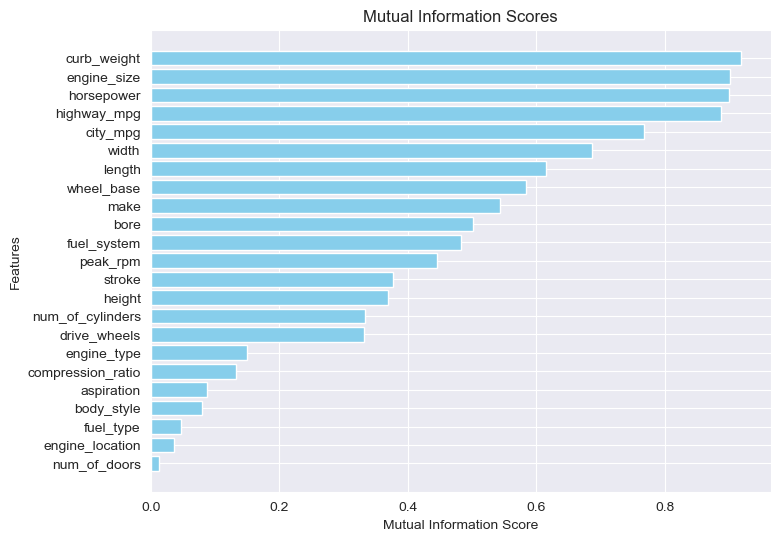

In [9]:
# Calculate and sort mutual information scores
mi_scores = mutual_info_regression(X_encoded, y, discrete_features=[col in discrete_features for col in X.columns])
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Printing sorted mutual information scores
print("Mutual Information Scores (sorted):")
for feature, score in mi_series.items():
    print(f"{feature}: {score}")

# Plotting with sorted values
plt.figure(figsize=(8, 6))
plt.barh(mi_series.index, mi_series.values, color="skyblue")
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.title('Mutual Information Scores')
plt.gca().invert_yaxis()  # To display the highest score at the top
plt.show()

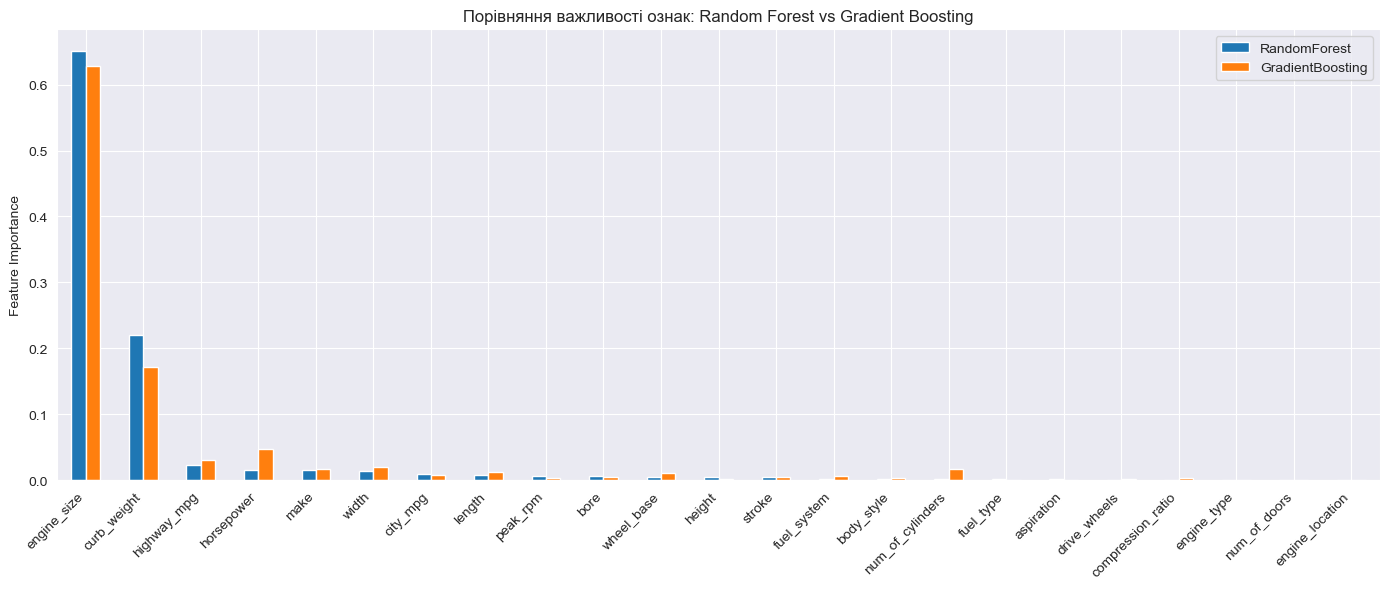

In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Модель Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_encoded, y)
rf_importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)

# Модель Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=0)
gb.fit(X_encoded, y)
gb_importance = pd.Series(gb.feature_importances_, index=X_encoded.columns)

# Об'єднання у DataFrame
importance_df = pd.DataFrame({
    'RandomForest': rf_importance,
    'GradientBoosting': gb_importance
})

# Сортування за RF важливістю для зручності
importance_df_sorted = importance_df.sort_values(by='RandomForest', ascending=False)

# Побудова графіку
importance_df_sorted.plot(kind='bar', figsize=(14, 6))
plt.title('Порівняння важливості ознак: Random Forest vs Gradient Boosting')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Створюємо загальний DataFrame з усіма оцінками
combined_scores = pd.DataFrame({
    'mutual_info': mi_series,
    'random_forest': rf_importance,
    'gradient_boosting': gb_importance
})

# Ранжування (нормалізоване: від 0 до 1)
ranked_scores = combined_scores.rank(pct=True)

# Вивід
print("Нормалізовані рангові оцінки:")
print(ranked_scores.sort_values(by='mutual_info', ascending=False))

Нормалізовані рангові оцінки:
                   mutual_info  random_forest  gradient_boosting
curb_weight           1.000000       0.956522           0.956522
engine_size           0.956522       1.000000           1.000000
horsepower            0.913043       0.869565           0.913043
highway_mpg           0.869565       0.913043           0.869565
city_mpg              0.826087       0.739130           0.608696
width                 0.782609       0.782609           0.826087
length                0.739130       0.695652           0.695652
wheel_base            0.695652       0.565217           0.652174
make                  0.652174       0.826087           0.739130
bore                  0.608696       0.608696           0.521739
fuel_system           0.565217       0.434783           0.565217
peak_rpm              0.521739       0.652174           0.434783
stroke                0.478261       0.478261           0.478261
height                0.434783       0.521739           0.26

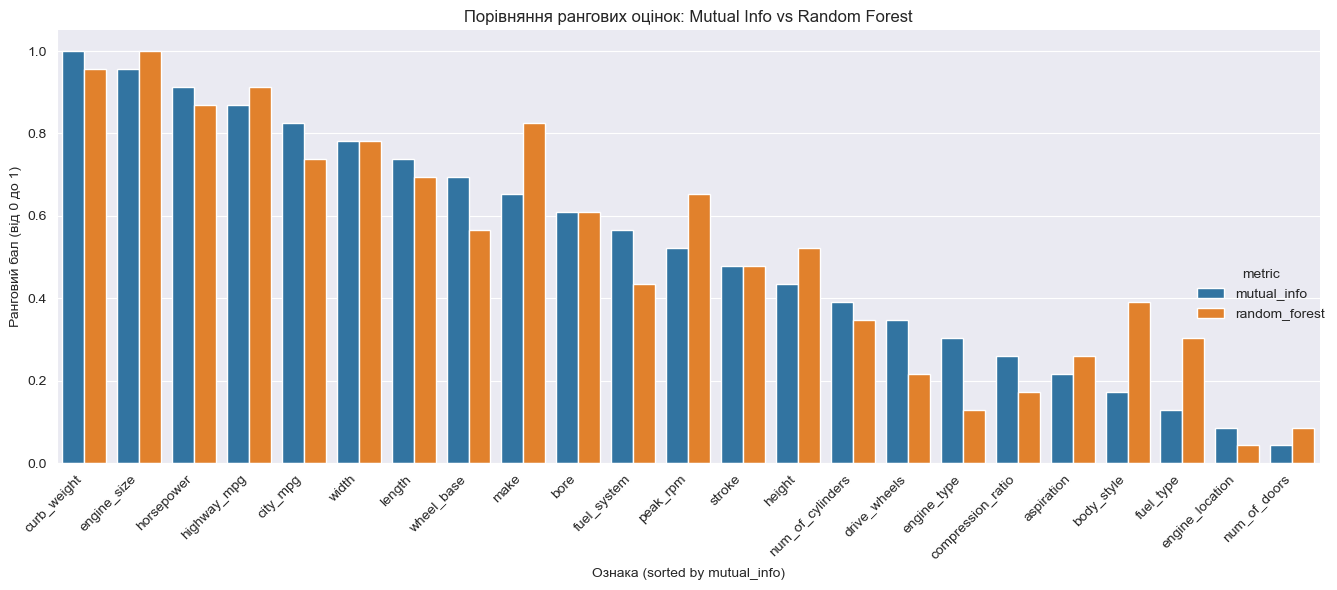

Топ ознак за ранговими оцінками (сортовано за mutual_info):

                   mutual_info  random_forest
curb_weight           1.000000       0.956522
engine_size           0.956522       1.000000
horsepower            0.913043       0.869565
highway_mpg           0.869565       0.913043
city_mpg              0.826087       0.739130
width                 0.782609       0.782609
length                0.739130       0.695652
wheel_base            0.695652       0.565217
make                  0.652174       0.826087
bore                  0.608696       0.608696
fuel_system           0.565217       0.434783
peak_rpm              0.521739       0.652174
stroke                0.478261       0.478261
height                0.434783       0.521739
num_of_cylinders      0.391304       0.347826
drive_wheels          0.347826       0.217391
engine_type           0.304348       0.130435
compression_ratio     0.260870       0.173913
aspiration            0.217391       0.260870
body_style         

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Вибираємо лише дві метрики
ranked_subset = ranked_scores[['mutual_info', 'random_forest']]

# Сортуємо за mutual_info
ranked_sorted = ranked_subset.sort_values(by='mutual_info', ascending=False)

# Перетворення в long format
ranked_melted = ranked_sorted.reset_index().melt(
    id_vars='index',
    value_vars=['mutual_info', 'random_forest'],
    var_name='metric',
    value_name='rank_score'
)

# Перейменування для виводу
ranked_melted = ranked_melted.rename(columns={'index': 'feature'})

# Побудова grouped barplot
g = sns.catplot(
    data=ranked_melted,
    kind='bar',
    x='feature',
    y='rank_score',
    hue='metric',
    height=6,
    aspect=2
)

# Оформлення
plt.xticks(rotation=45, ha='right')
plt.title('Порівняння рангових оцінок: Mutual Info vs Random Forest')
plt.ylabel('Ранговий бал (від 0 до 1)')
plt.xlabel('Ознака (sorted by mutual_info)')
plt.tight_layout()
plt.show()

# Вивід в консоль у вигляді таблиці
print("Топ ознак за ранговими оцінками (сортовано за mutual_info):\n")
print(ranked_sorted)

## Аналіз важливості ознак (на основі mutual_info та Random Forest)

###Топ ознаки з високим впливом (в обох метриках)

| Ознака        | Mutual Info | Random Forest |
|---------------|-------------|----------------|
| `curb_weight` | **1.00**    | **0.96**       |
| `engine_size` | **0.96**    | **1.00**       |
| `highway_mpg` | 0.91        | 0.91           |
| `horsepower`  | 0.87        | 0.87           |

Ці ознаки мають найвищу інформативність і найбільше впливають на ціну (`price`). Логічно, бо пов'язані з потужністю та розмірами авто.

---

### Ознаки з високим mutual_info, але нижчою важливістю в моделі

| Ознака         | Mutual Info | Random Forest |
|----------------|-------------|----------------|
| `fuel_system`  | 0.61        | 0.43           |
| `wheel_base`   | 0.70        | 0.57           |
| `bore`         | 0.57        | 0.61           |
| `drive_wheels` | 0.39        | 0.22           |

Можливо, ці змінні мають інформацію, яку модель вважає надлишковою бо вони пояснені через інші фічі.

---

### Ознаки з вищою важливістю у моделі, ніж у mutual_info

| Ознака         | Mutual Info | Random Forest |
|----------------|-------------|----------------|
| `make`         | 0.65        | **0.83**       |
| `peak_rpm`     | 0.52        | **0.65**       |
| `body_style`   | 0.17        | **0.39**       |
| `fuel_type`    | 0.13        | **0.30**       |

Ймовірно, модель вловлює складні або непрямі залежності, які `mutual_info` не бачить.

---

### Найменш важливі ознаки

| Ознака             | Mutual Info | Random Forest |
|--------------------|-------------|----------------|
| `num_of_doors`     | 0.04        | 0.09           |
| `engine_location`  | 0.09        | 0.04           |
| `fuel_type`        | 0.13        | 0.30           |

Мають низьке значення в обох оцінках — кандидати на виключення або трансформацію.

---

## Висновки:

1. `curb_weight`, `engine_size`, `horsepower`, `highway_mpg` — **ключові змінні** для моделювання ціни.
2. Деякі ознаки несуть інформацію, але модель її **не використовує ефективно**.
3. `RandomForest` може виявити **складніші взаємозв’язки**, ніж `mutual_info`.
